In [1]:
import sys
!{sys.executable} -m pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Kernel working")

C:\Users\winnie\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kernel working


In [3]:
# Load Dataset A
df = pd.read_csv("set A corporate_rating.csv")

print("Dataset loaded successfully")
print("Rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns)

Dataset loaded successfully
Rows and columns: (2029, 31)

Column names:
Index(['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector',
       'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding',
       'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin',
       'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed',
       'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover',
       'debtEquityRatio', 'debtRatio', 'effectiveTaxRate',
       'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare',
       'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue',
       'enterpriseValueMultiple', 'operatingCashFlowPerShare',
       'operatingCashFlowSalesRatio', 'payablesTurnover'],
      dtype='str')


In [4]:
# Select all useful financial columns
features = [
    "currentRatio",
    "quickRatio",
    "cashRatio",
    "daysOfSalesOutstanding",
    "netProfitMargin",
    "pretaxProfitMargin",
    "grossProfitMargin",
    "operatingProfitMargin",
    "returnOnAssets",
    "returnOnCapitalEmployed",
    "returnOnEquity",
    "assetTurnover",
    "fixedAssetTurnover",
    "debtEquityRatio",
    "debtRatio",
    "effectiveTaxRate",
    "freeCashFlowOperatingCashFlowRatio",
    "freeCashFlowPerShare",
    "cashPerShare",
    "companyEquityMultiplier",
    "ebitPerRevenue",
    "enterpriseValueMultiple",
    "operatingCashFlowPerShare",
    "operatingCashFlowSalesRatio",
    "payablesTurnover"
]

X = df[features]

In [5]:
# Convert Rating into 4 credit risk categories
def convert_rating(rating):
    if rating in ["AAA", "AA", "A"]:
        return "Investment-High"
    elif rating == "BBB":
        return "Investment-Low"
    elif rating in ["BB", "B"]:
        return "Speculative"
    elif rating in ["CCC", "CC", "C", "D"]:
        return "Distressed"
    else:
        return "Unknown"

df["Risk_Category"] = df["Rating"].apply(convert_rating)
y = df["Risk_Category"]

print("\nRisk category counts:")
print(df["Risk_Category"].value_counts())


Risk category counts:
Risk_Category
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64


In [6]:
# Fill missing values with median
X = X.fillna(X.median())

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [8]:
# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully")
print("Risk categories:", model.classes_)

Model trained successfully
Risk categories: ['Distressed' 'Investment-High' 'Investment-Low' 'Speculative']


In [9]:
print(model.classes_)

['Distressed' 'Investment-High' 'Investment-Low' 'Speculative']


In [10]:
# Prediction 
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy:
0.6617405582922824

Confusion Matrix:
[[  2   1   0  19]
 [  0  89  43  16]
 [  0  39 114  48]
 [  1  10  29 198]]

Classification Report:
                 precision    recall  f1-score   support

     Distressed       0.67      0.09      0.16        22
Investment-High       0.64      0.60      0.62       148
 Investment-Low       0.61      0.57      0.59       201
    Speculative       0.70      0.83      0.76       238

       accuracy                           0.66       609
      macro avg       0.66      0.52      0.53       609
   weighted avg       0.66      0.66      0.65       609



In [11]:
# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

class_names = list(model.classes_)

print("SHAP values created successfully")
print("Class names:", class_names)

SHAP values created successfully
Class names: ['Distressed', 'Investment-High', 'Investment-Low', 'Speculative']


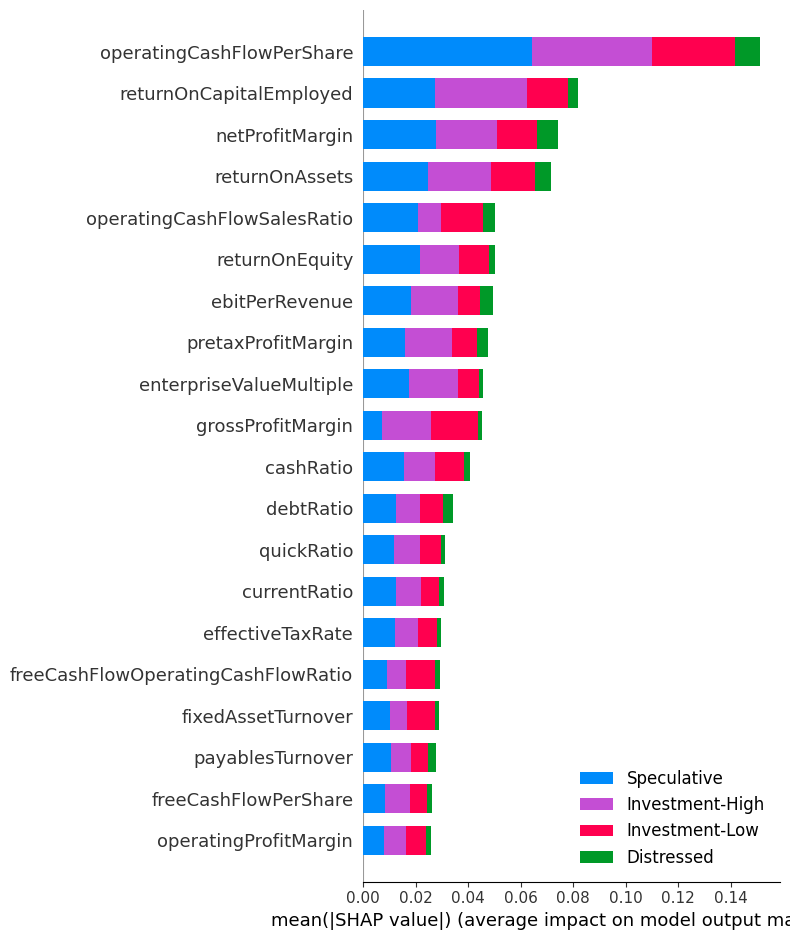

In [12]:
# SHAP summary plot
if isinstance(shap_values, list):
    shap_values_for_plot = shap_values
else:
    shap_values_for_plot = [
        shap_values[:, :, i] for i in range(shap_values.shape[2])
    ]

shap.summary_plot(
    shap_values_for_plot,
    X_test,
    feature_names=features,
    class_names=class_names
)

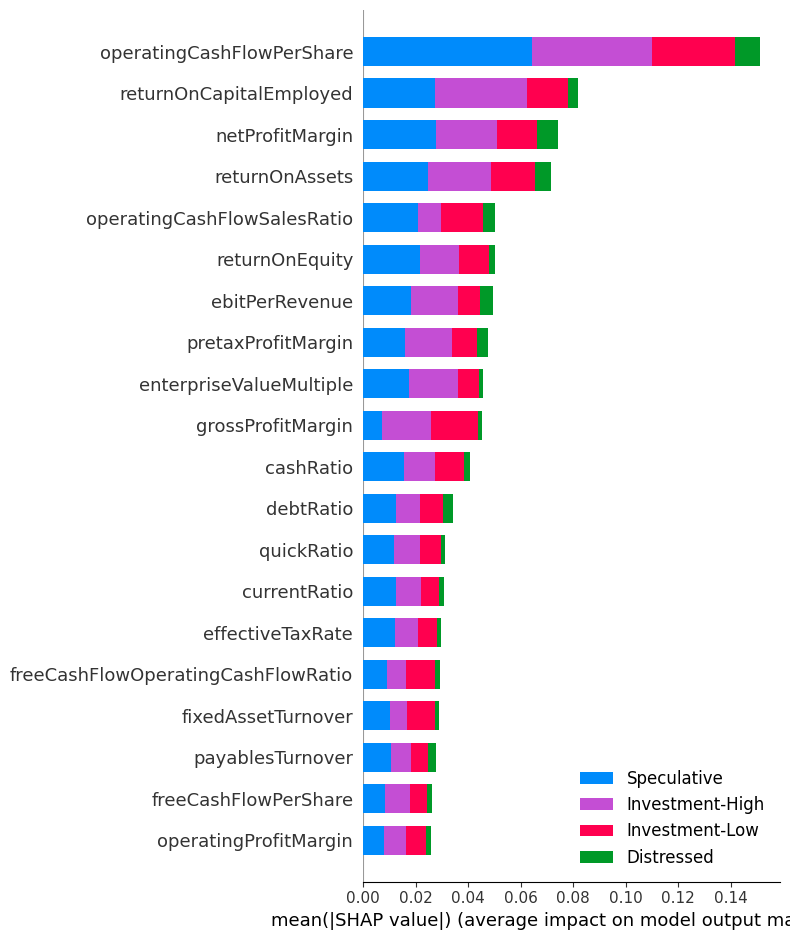

In [13]:
# SHAP bar chart
shap.summary_plot(
    shap_values_for_plot,
    X_test,
    feature_names=features,
    class_names=class_names,
    plot_type="bar"
)

In [14]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
importance


Feature Importance:


,Feature,Importance
22,operatingCashFlowPerShare,0.071424
9,returnOnCapitalEmployed,0.051497
4,netProfitMargin,0.048901
8,returnOnAssets,0.046913
23,operatingCashFlowSalesRatio,0.045976
2,cashRatio,0.043709
21,enterpriseValueMultiple,0.043610
10,returnOnEquity,0.040683
12,fixedAssetTurnover,0.039703
16,freeCashFlowOperatingCashFlowRatio,0.039622
